In [1]:
import re
import numpy as np
import sklearn as sns
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings

<function warnings.filterwarnings(action, message='', category=<class 'Warning'>, module='', lineno=0, append=False)>

In [2]:
df = pd.read_excel('Online Retail.xlsx')

In [3]:
print("\n--- TỔNG QUAN DỮ LIỆU ---")
print(f"Kích thước dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")
print(df.info())


--- TỔNG QUAN DỮ LIỆU ---
Kích thước dữ liệu: 541909 dòng, 8 cột
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None


In [4]:
print("\n--- KIỂM TRA GIÁ TRỊ RỖNG ---")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({'Số lượng rỗng': missing_data, 'Tỷ lệ (%)': missing_percent})
print(missing_data)
print(missing_df[missing_df['Số lượng rỗng'] > 0])


--- KIỂM TRA GIÁ TRỊ RỖNG ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
             Số lượng rỗng  Tỷ lệ (%)
Description           1454   0.268311
CustomerID          135080  24.926694


In [5]:
# 4. Phân tích bất thường (Thống kê mô tả)
print("\n--- THỐNG KÊ MÔ TẢ CÁC CỘT SỐ ---")
display(df.describe(include='all'))


--- THỐNG KÊ MÔ TẢ CÁC CỘT SỐ ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


In [6]:
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
cancelled_orders = df[df['InvoiceNo'].str.startswith('C')]
print(f"\nSố lượng giao dịch bị hủy (Invoice bắt đầu bằng 'C'): {len(cancelled_orders)}")
print(f"Số lượng giao dịch có Quantity âm: {len(df[df['Quantity'] <= 0])}")


Số lượng giao dịch bị hủy (Invoice bắt đầu bằng 'C'): 9288
Số lượng giao dịch có Quantity âm: 10624


In [7]:
print("\n--- ĐẶC TRƯNG CHUỖI KHÁCH HÀNG ---")
print(f"Thời gian bắt đầu: {df['InvoiceDate'].min()}")
print(f"Thời gian kết thúc: {df['InvoiceDate'].max()}")
print(f"Số lượng khách hàng duy nhất: {df['CustomerID'].nunique()}")
print(f"Số lượng mặt hàng (StockCode) duy nhất: {df['StockCode'].nunique()}")


--- ĐẶC TRƯNG CHUỖI KHÁCH HÀNG ---
Thời gian bắt đầu: 2010-12-01 08:26:00
Thời gian kết thúc: 2011-12-09 12:50:00
Số lượng khách hàng duy nhất: 4372
Số lượng mặt hàng (StockCode) duy nhất: 4070


In [8]:
temp_df = df.dropna(subset=['CustomerID'])
visits_per_customer = temp_df.groupby('CustomerID')['InvoiceNo'].nunique()

print(f"\nTrung bình một khách có bao nhiêu hóa đơn (lần ghé thăm): {visits_per_customer.mean():.2f}")
print(f"Khách hàng mua nhiều lần nhất: {visits_per_customer.max()} lần")


Trung bình một khách có bao nhiêu hóa đơn (lần ghé thăm): 5.08
Khách hàng mua nhiều lần nhất: 248 lần


In [9]:
print("\n--- BƯỚC 1: LÀM SẠCH DỮ LIỆU ---")
df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
df_clean = df_clean[df_clean['StockCode'].astype(str).str.contains(r'\d', regex=True, na=False)]
df_clean = df_clean.drop_duplicates()
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
print(f"-> Số dòng gốc: {len(df)}")
print(f"-> Số dòng sau khi làm sạch (df_clean): {len(df_clean)}")


--- BƯỚC 1: LÀM SẠCH DỮ LIỆU ---
-> Số dòng gốc: 541909
-> Số dòng sau khi làm sạch (df_clean): 391283


In [10]:
print("\n--- BƯỚC 2: TẠO CHUỖI TUẦN TỰ (SEQUENCES) ---")

df_clean = df_clean.sort_values(by=['CustomerID', 'InvoiceDate'])
df_clean['StockCode'] = df_clean['StockCode'].astype(str).str.strip()

print("-> Đang gom nhóm các sản phẩm cùng 1 hóa đơn...")

itemsets = df_clean.groupby(['CustomerID', 'InvoiceNo', 'InvoiceDate'])['StockCode'].apply(lambda x: sorted(list(set(x)))).reset_index()

print("\n--- KẾT QUẢ TẠO GIỎ HÀNG (ITEMSETS)---")
display(itemsets.head())

print("\n-> Đang nối các giỏ hàng thành chuỗi hành vi của từng khách hàng...")
sequences = itemsets.groupby('CustomerID')['StockCode'].apply(list).reset_index()

print("\n--- KẾT QUẢ TẠO CHUỖI TUẦN TỰ (SEQUENCES) ---")
display(sequences.head())
output_filename = 'prefixspan_online_retail.txt'

with open(output_filename, 'w', encoding='utf-8') as f:
    for seq in sequences['StockCode']:
        seq_str = ""
        for itemset in seq:
            itemset_str = " ".join(itemset)
            seq_str += f"{itemset_str} -1 "

        seq_str += "-2\n"
        f.write(seq_str)

print(f"Xử lý hoàn tất. Tập dữ liệu gồm {len(sequences)} chuỗi tuần tự đã được lưu tại: {output_filename}")



--- BƯỚC 2: TẠO CHUỖI TUẦN TỰ (SEQUENCES) ---
-> Đang gom nhóm các sản phẩm cùng 1 hóa đơn...

--- KẾT QUẢ TẠO GIỎ HÀNG (ITEMSETS)---


,CustomerID,InvoiceNo,InvoiceDate,StockCode
0,12346.0,541431,2011-01-18 10:01:00,[23166]
1,12347.0,537626,2010-12-07 14:57:00,"[20780, 20782, 21064, 21171, 21731, 22195, 222..."
2,12347.0,542237,2011-01-26 14:30:00,"[20719, 20966, 21035, 21041, 21154, 21731, 218..."
3,12347.0,549222,2011-04-07 10:43:00,"[16008, 20665, 21041, 21731, 21791, 21975, 221..."
4,12347.0,556201,2011-06-09 13:01:00,"[17021, 22196, 22371, 22375, 22725, 22727, 230..."



-> Đang nối các giỏ hàng thành chuỗi hành vi của từng khách hàng...

--- KẾT QUẢ TẠO CHUỖI TUẦN TỰ (SEQUENCES) ---


,CustomerID,StockCode
0,12346.0,[[23166]]
1,12347.0,"[[20780, 20782, 21064, 21171, 21731, 22195, 22..."
2,12348.0,"[[21211, 21213, 21725, 21977, 21981, 21982, 22..."
3,12349.0,"[[20685, 20914, 21086, 21136, 21231, 21232, 21..."
4,12350.0,"[[20615, 20652, 21171, 21832, 21864, 21866, 21..."


Xử lý hoàn tất. Tập dữ liệu gồm 4334 chuỗi tuần tự đã được lưu tại: prefixspan_online_retail.txt


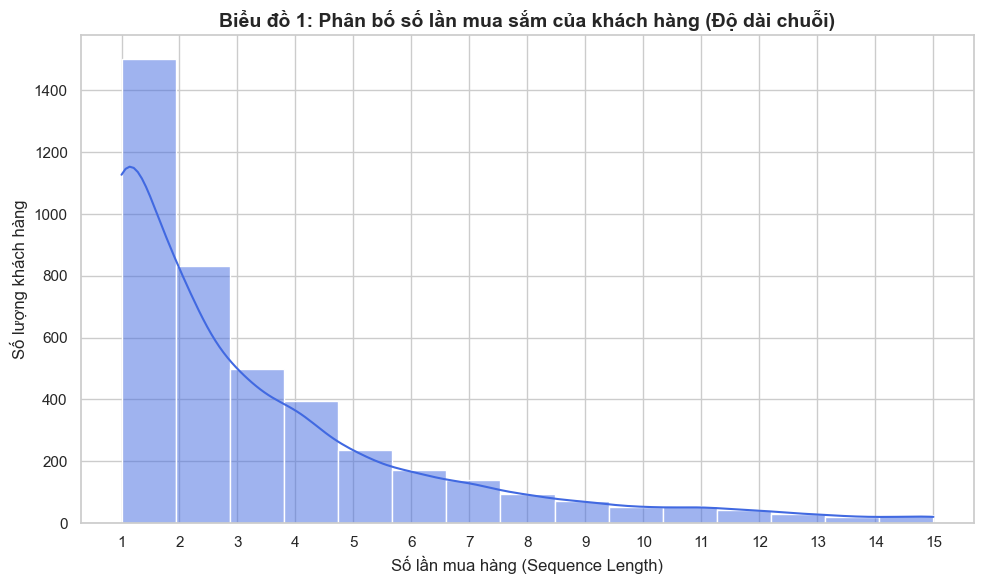

In [11]:
sns.set_theme(style="whitegrid")
sequence_lengths = sequences['StockCode'].apply(len)
plt.figure(figsize=(10, 6))
# Giới hạn xem các khách hàng mua dưới 15 lần để biểu đồ không bị nhiễu bởi các outlier
sns.histplot(sequence_lengths[sequence_lengths <= 15], bins=15, color='royalblue', kde=True)

plt.title('Biểu đồ 1: Phân bố số lần mua sắm của khách hàng (Độ dài chuỗi)', fontsize=14, fontweight='bold')
plt.xlabel('Số lần mua hàng (Sequence Length)', fontsize=12)
plt.ylabel('Số lượng khách hàng', fontsize=12)
plt.xticks(range(1, 16))
plt.tight_layout()
plt.show()

C:\Users\Tun tun\AppData\Local\Temp\ipykernel_23188\1334107236.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top10, x='Mã sản phẩm (StockCode)', y='Tần suất xuất hiện (Support count)', palette='viridis')


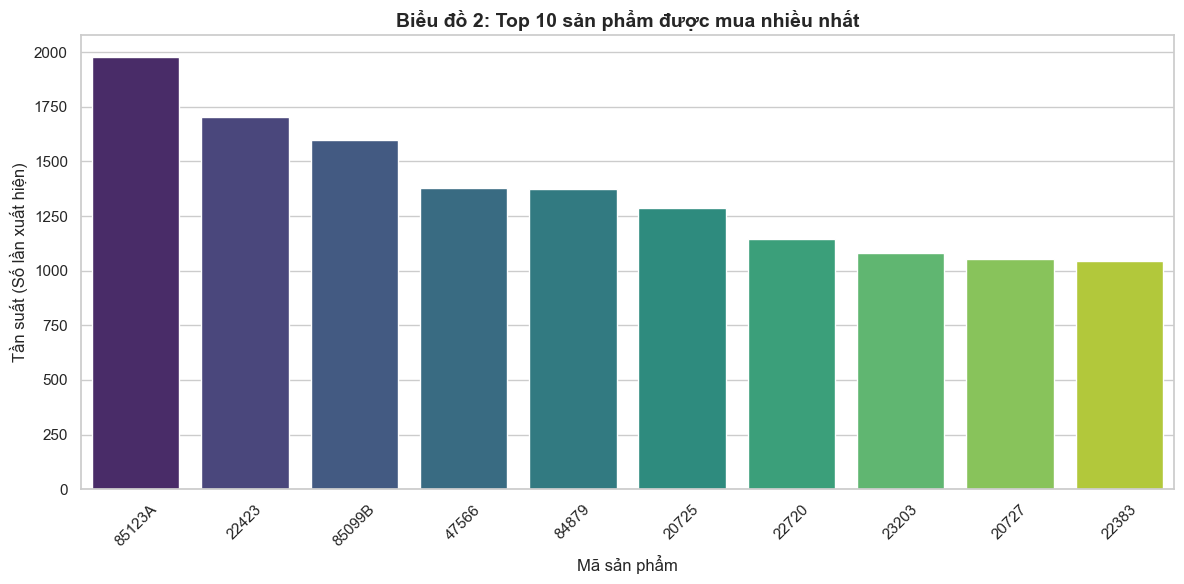

In [12]:
from collections import Counter
all_items = []
for seq in sequences['StockCode']:
    for itemset in seq:
        all_items.extend(itemset)

item_counts = Counter(all_items)
top_10_items = item_counts.most_common(10)
table2_data = {
    'Mã sản phẩm (StockCode)': [x[0] for x in top_10_items],
    'Tần suất xuất hiện (Support count)': [x[1] for x in top_10_items]
}
df_top10 = pd.DataFrame(table2_data)
plt.figure(figsize=(12, 6))
sns.barplot(data=df_top10, x='Mã sản phẩm (StockCode)', y='Tần suất xuất hiện (Support count)', palette='viridis')

plt.title('Biểu đồ 2: Top 10 sản phẩm được mua nhiều nhất', fontsize=14, fontweight='bold')
plt.xlabel('Mã sản phẩm', fontsize=12)
plt.ylabel('Tần suất (Số lần xuất hiện)', fontsize=12)
# Xoay nhãn trục x nếu cần
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:

from collections import Counter
itemset_sizes = itemsets['StockCode'].apply(len)
size_counts = itemset_sizes.value_counts().sort_index().head(10)

table_size_data = {
    'Số lượng sản phẩm / 1 lần mua (Itemset Size)': size_counts.index,
    'Số lượng giỏ hàng (Tần suất)': size_counts.values,
    'Tỷ lệ (%)': np.round((size_counts.values / len(itemsets)) * 100, 2)
}
df_itemset_size = pd.DataFrame(table_size_data)

print("\nBẢNG 3: PHÂN BỐ KÍCH THƯỚC GIỎ HÀNG TRONG 1 LẦN GIAO DỊCH")
print("-" * 65)
print(df_itemset_size.to_string(index=False))


BẢNG 3: PHÂN BỐ KÍCH THƯỚC GIỎ HÀNG TRONG 1 LẦN GIAO DỊCH
-----------------------------------------------------------------
 Số lượng sản phẩm / 1 lần mua (Itemset Size)  Số lượng giỏ hàng (Tần suất)  Tỷ lệ (%)
                                            1                          1321       7.17
                                            2                           720       3.91
                                            3                           641       3.48
                                            4                           639       3.47
                                            5                           649       3.52
                                            6                           601       3.26
                                            7                           589       3.20
                                            8                           589       3.20
                                            9                           609       3.30
     

In [14]:
transitions = []

for seq in sequences['StockCode']:
    if len(seq) > 1:
        for i in range(len(seq) - 1):
            itemset_current = seq[i]
            itemset_next = seq[i+1]
            for item1 in itemset_current:
                for item2 in itemset_next:
                    transitions.append(f"{item1} -> {item2}")

top_transitions = Counter(transitions).most_common(10)

table_transition_data = {
    'Mẫu chuỗi 2 phần tử (Transition)': [x[0] for x in top_transitions],
    'Số lần xuất hiện': [x[1] for x in top_transitions]
}
df_transitions = pd.DataFrame(table_transition_data)
print("\nBẢNG 4: TOP 10 CẶP SẢN PHẨM ĐƯỢC MUA LIÊN TIẾP NHAU (CHUYỂN ĐỔI 1 BƯỚC)")
print("-" * 65)
print(df_transitions.to_string(index=False))


BẢNG 4: TOP 10 CẶP SẢN PHẨM ĐƯỢC MUA LIÊN TIẾP NHAU (CHUYỂN ĐỔI 1 BƯỚC)
-----------------------------------------------------------------
Mẫu chuỗi 2 phần tử (Transition)  Số lần xuất hiện
                85123A -> 85123A               605
                85099B -> 85099B               435
                  22423 -> 22423               367
                  84879 -> 84879               366
                  20725 -> 20725               347
                  47566 -> 47566               346
                  22197 -> 22197               334
                  23203 -> 23203               330
                  22383 -> 22383               309
                 85099B -> 23203               307
